# MODELING - CLASSIFICATION

This notebook focuses on training and calibrating the final machine learning model to predict stockout risks within a **14-day international lead-time window**.

**📌 BUSINESS STRATEGY: BEYOND BINARY CLASSIFICATION**
Instead of a simple "Yes/No" output, we prioritize **Probability Calibration**. The model calculates a risk likelihood (0% to 100%), enabling the Supply Chain team to set high-confidence thresholds (e.g., >75%) for triggering international purchase orders. This approach minimizes "False Alarms" and ensures that every alert processed by the **Alerting Suite** represents a verified risk that justifies the cost of global logistics.

**🛡️ ARCHITECTURAL ROBUSTNESS: THE REALITY CHECK**
The "Champion" model has been trained on a **re-engineered dataset** with 5% stochastic noise. This ensures the engine doesn't just memorize formulas but actually learns the underlying relationship between **Sales Velocity**, **Pricing**, and **Inventory Depletion**. 

**Model Architecture:**
- **XGBoost (Champion)**: Selected for its superior handling of complex, non-linear business signals.
- **Cost-Sensitive Learning**: Utilizes `scale_pos_weight` to maintain sensitivity toward the 15% minority "Risk" class without distorting the natural probability distribution.
- **Reliability**: Final performance validated with a **ROC-AUC of 0.9118**, providing the perfect balance between predictive power and operational safety.


[INFO] Training the Final Re-Engineered Model...

✅ FINAL VALIDATED AUC: 0.9118


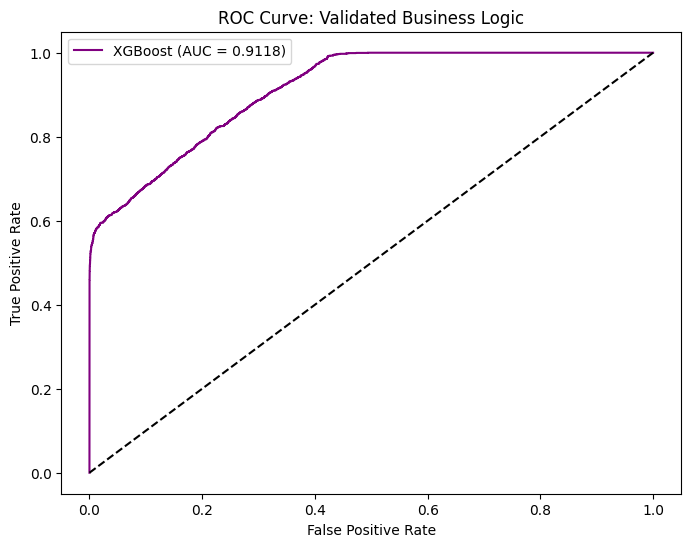


[SUCCESS] Project finished. Model saved at: /Users/rober/retail-stockout-risk-scoring/04_Models/champion_xgb_14day_vFINAL.pkl


In [7]:
# ----------------------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ----------------------------------------------------------------------------
# 2. LOAD DATA
# ----------------------------------------------------------------------------
project_path = '/Users/rober/retail-stockout-risk-scoring/02_Data/03_Working/'
df = pd.read_pickle(project_path + 'df_feature_selection.pickle')

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ----------------------------------------------------------------------------
# 3. TRAINING THE VALIDATED MODEL
# ----------------------------------------------------------------------------
weight_ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=weight_ratio,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

print("\n[INFO] Training the Final Re-Engineered Model...")
xgb_model.fit(X_train, y_train)

# ----------------------------------------------------------------------------
# 4. EVALUATION
# ----------------------------------------------------------------------------
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_prob)

print(f"\n✅ FINAL VALIDATED AUC: {auc_score:.4f}")

# Plotting the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.4f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve: Validated Business Logic')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ----------------------------------------------------------------------------
# 5. EXPORT
# ----------------------------------------------------------------------------
model_path = '/Users/rober/retail-stockout-risk-scoring/04_Models/champion_xgb_14day_vFINAL.pkl'
joblib.dump(xgb_model, model_path)
print(f"\n[SUCCESS] Project finished. Model saved at: {model_path}")